Dataset Shape: (15818, 8)
Columns: ['Crop', 'N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Season']

🎯 Season Encoding: {'Kharif': 0, 'Rabi': 1, 'Zaid': 2}

🌾 Crop Encoding Completed!

⭐ Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

📌 TRAIN Accuracy: 96.08%
📌 TEST Accuracy: 93.99%

📊 CLASSIFICATION REPORT (TEST DATA):
              precision    recall  f1-score   support

      barley       1.00      1.00      1.00       131
 bittergourd       1.00      1.00      1.00         2
   blackgram       1.00      1.00      1.00         2
 bottlegourd       1.00      1.00      1.00         3
     brinjal       1.00      1.00      1.00        11
     cabbage       1.00      1.00      1.00         5
 cauliflower       1.00      1.00      1.00         5
   coriander       1.00      1.00      1.00        95
    cucumber       1.00      1.00      1.00         4
      garlic       1.00      1.00      1.00        83
   horsegram   

<Figure size 1200x800 with 0 Axes>

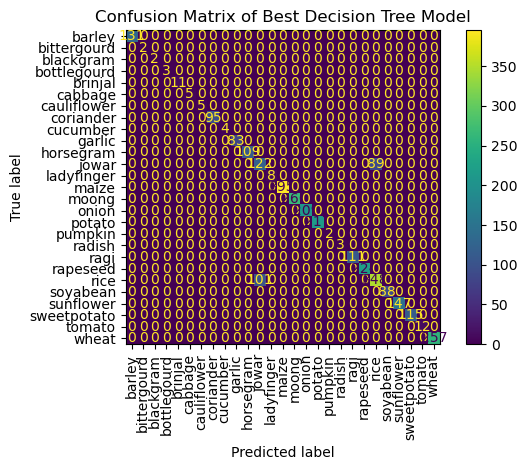


💾 Saving model into .pkl ...
🎉 Model saved as crop_recommendation_model.pkl
   🔹 Works 100% with Rotation Model


In [2]:
# ============================================================
# 🌾 FINAL TRAINING SCRIPT — GENERATES crop_recommendation_model.pkl
# Works perfectly with the Seasonal Crop Rotation Model
# ============================================================

# Importing essential libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# STEP 1: Load dataset
# ============================================================
dataset_path = r"C:\Users\cheth\OneDrive\Documents\Desktop\datasests\agricultural_data_with_season.csv"
crop_data = pd.read_csv(dataset_path)
crop_data = crop_data.drop(columns=['Unnamed: 0'], errors='ignore')

print("Dataset Shape:", crop_data.shape)
print("Columns:", list(crop_data.columns))

# ============================================================
# STEP 2: Encode categorical columns
# ============================================================
label_encoder_season = LabelEncoder()
crop_data["Season_Label"] = label_encoder_season.fit_transform(crop_data["Season"])

label_encoder_crop = LabelEncoder()
crop_data["Crop_Label"] = label_encoder_crop.fit_transform(crop_data["Crop"])

print("\n🎯 Season Encoding:", dict(zip(label_encoder_season.classes_,
                                     label_encoder_season.transform(label_encoder_season.classes_))))
print("\n🌾 Crop Encoding Completed!")

# ============================================================
# STEP 3: Feature & Label Separation
# ============================================================
# Remove text columns — ML model uses numeric features only
X = crop_data.drop(columns=["Crop", "Crop_Label", "Season"])
y = crop_data["Crop_Label"]

# ============================================================
# STEP 4: Train-Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# STEP 5: Standard Scaling
# ============================================================
X_train_numeric = X_train
X_test_numeric = X_test

numeric_feature_names = list(X_train_numeric.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# ============================================================
# STEP 6: Hyperparameter Tuning (GridSearchCV)
# ============================================================
params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1_macro"
)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print("\n⭐ Best Hyperparameters:", grid.best_params_)

# ============================================================
# STEP 7: Evaluate Model
# ============================================================
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)

print("\n📌 TRAIN Accuracy: {:.2f}%".format(accuracy_score(y_train, y_pred_train) * 100))
print("📌 TEST Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_test) * 100))

print("\n📊 CLASSIFICATION REPORT (TEST DATA):")
print(classification_report(y_test, y_pred_test, zero_division=1, target_names=label_encoder_crop.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test),
                       display_labels=label_encoder_crop.classes_).plot(xticks_rotation=90)
plt.title("Confusion Matrix of Best Decision Tree Model")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 8: Save .pkl model for Crop Rotation System
# ============================================================
print("\n💾 Saving model into .pkl ...")

model_data = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": label_encoder_crop,          # crop encoder
    "label_encoder_season": label_encoder_season, # season encoder
    "numeric_feature_names": numeric_feature_names,
    "feature_names": numeric_feature_names        # ensures same feature order
}

with open("crop_recommendation_model01.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("==============================================")
print("🎉 Model saved as crop_recommendation_model.pkl")
print("   🔹 Works 100% with Rotation Model")
print("==============================================")


In [ ]:
import os
print("Saved at:", os.path.abspath("crop_recommendation_model01.pkl"))


In [5]:
import pickle
import pandas as pd

# ==========================
# Load saved model and tools
# ==========================
pkl_path = "crop_recommendation_model01.pkl"   # update if path different

with open(pkl_path, 'rb') as f:
    model_data = pickle.load(f)

model = model_data["model"]
scaler = model_data["scaler"]
label_encoder = model_data["label_encoder"]
label_encoder_season = model_data["label_encoder_season"]
numeric_feature_names = model_data["numeric_feature_names"]

print("🌟 Model & preprocessors loaded successfully!\n")

# ==========================
# User Input for Prediction
# ==========================

# Modify or replace these input values
N = float(input("Enter Nitrogen (N): ") or 80)
P = float(input("Enter Phosphorus (P): ") or 60)
K = float(input("Enter Potassium (K): ") or 20)
pH = float(input("Enter Soil pH: ") or 6.0)
rainfall = float(input("Enter Rainfall (mm): ") or 250)
temperature = float(input("Enter Temperature (°C): ") or 28)
season = input("Enter season (Kharif / Rabi / Zaid): ") or "Kharif"

# ==========================
# Prepare input for model
# ==========================

# Encode Season
season_label = label_encoder_season.transform([season])[0]

sample = {
    "N": N,
    "P": P,
    "K": K,
    "temperature": temperature,
    "pH": pH,
    "rainfall": rainfall,
    "Season_Label": season_label
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample])

# Ensure same column order as training
sample_df = sample_df.reindex(columns=numeric_feature_names, fill_value=0)

# Apply scaling
sample_scaled = scaler.transform(sample_df)

# Predict crop
predicted_label = model.predict(sample_scaled)[0]
predicted_crop = label_encoder.inverse_transform([predicted_label])[0]

print("\n============================================")
print(f"🌿 Recommended Crop for Given Conditions: {predicted_crop.upper()}")
print("============================================")


🌟 Model & preprocessors loaded successfully!



Enter Nitrogen (N):  20
Enter Phosphorus (P):  40
Enter Potassium (K):  40
Enter Soil pH:  5
Enter Rainfall (mm):  300
Enter Temperature (°C):  27
Enter season (Kharif / Rabi / Zaid):  Zaid



🌿 Recommended Crop for Given Conditions: BARLEY
